# EDA de riesgo de crédito de la banca privada del Ecuador (enero - agosto 2026)

**Proyecto final · Dashboard EDA por profesión** · Profesión: **Finanzas (análisis de riesgo de crédito)**

Datos reales de la Superintendencia de Bancos (Portal Estadístico, *Cartera y Depósitos*, Año 2026, banca privada, corte agosto 2026).

El notebook sigue los 7 pasos del EDA del curso:
1. Pregunta · 2. Estructura · 3. Univariado · 4. Bivariado · 5. Faltantes y atípicos · 6. Segmentación · 7. Hallazgos

## Paso 1 · Pregunta

**Profesión y problema real.** Un analista de riesgo de crédito de un banco privado debe decidir dónde colocar crédito y dónde reforzar provisiones. En 2026 hay incertidumbre adicional por el Fenómeno de El Niño previsto para el país, y la morosidad no se reparte de forma pareja entre tipos de crédito ni entre zonas.

**Pregunta central.** ¿Qué segmentos de crédito, zonas del país y entidades concentran más riesgo de morosidad en la banca privada, y dónde conviene reforzar provisiones, moderar o ampliar la colocación?

**Decisiones que apoya el dashboard**
1. En qué segmento y región reforzar provisiones o endurecer políticas de colocación.
2. En qué combinaciones segmento-región la morosidad es baja y la cartera crece (candidatas a ampliar colocación).
3. Qué entidades concentran la cartera improductiva (dónde mirar primero).

**Hipótesis de partida**
- H1: microcrédito y consumo son más morosos que productivo e inmobiliario.
- H2: la morosidad difiere entre regiones (Costa, Sierra, Oriente, Insular).
- H3: pocas entidades concentran la mayor parte de los dólares improductivos.

**Métrica clave.** Cartera improductiva = *no devenga intereses* + *vencida*. Morosidad (%) = improductiva / saldo total x 100. Para agrupar se usa la morosidad **ponderada** (suma de improductiva / suma de saldo), nunca el promedio simple de porcentajes.

## Paso 2 · Estructura

Se cargan los 4 archivos Excel descargados (consumo, productivo, microcrédito y vivienda). Cada libro trae una hoja tipo reporte (con celdas combinadas) y una hoja **BASE** ya en formato de tabla. Se usan solo las hojas BASE.

**Librerías y rutas.** Importa las librerías (pandas y numpy para datos, matplotlib y seaborn para gráficos), define estilo y localiza la carpeta data/raw donde están los Excel originales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

# Carpeta del proyecto (funciona ejecutando desde /notebooks o desde la raiz)
RAIZ = Path("..") if Path("../data/raw").exists() else Path(".")
RAW = RAIZ / "data" / "raw"
PROCESADO = RAIZ / "data" / "processed"
print("Archivos de entrada:")
for f in sorted(RAW.glob("*.xlsx")):
    print(" -", f.name)

Archivos de entrada:
 - COLOCACIONES_BANCA_PRIVADA_CONSUMO_2026_08.xlsx
 - COLOCACIONES_BANCA_PRIVADA_MICROCREDITO_2026_08.xlsx
 - COLOCACIONES_BANCA_PRIVADA_PRODUCTIVO_2026_08.xlsx
 - COLOCACIONES_BANCA_PRIVADA_VIVIENDA_2026_08.xlsx


**Carga y unión de los 4 archivos.** Lee cada libro Excel y toma únicamente las hojas que empiezan con «BASE». Usa header=1 porque el encabezado está en la segunda fila, elimina la primera columna vacía, nombra las columnas y rellena hacia abajo el segmento (ffill) porque solo está escrito en la primera fila. Une todo con pd.concat y acorta los nombres de los bancos.

In [2]:
COLUMNAS = ["segmento", "fecha", "entidad", "provincia", "canton",
            "por_vencer", "no_devenga", "vencida", "saldo_total"]

def entidad_corta(nombre):
    """Acorta los nombres de banco para que quepan en los graficos."""
    n = " ".join(nombre.split())
    if "CODESARROLLO" in n:
        return "CODESARROLLO"
    if "AMIBANK" in n:
        return "AMIBANK (liquidacion)"
    if "VISIONFUND" in n:
        return "VISIONFUND"
    return n.replace("BP ", "").replace("BANCO ", "").replace(" S.A.", "")

tablas = []
for archivo in sorted(RAW.glob("*.xlsx")):
    libro = pd.ExcelFile(archivo)
    for hoja in libro.sheet_names:
        if hoja.startswith("BASE"):                    # solo hojas en formato tabla
            t = libro.parse(hoja, header=1).iloc[:, 1:]   # fila 2 = encabezado; se quita col. A vacia
            t.columns = COLUMNAS
            t["segmento"] = t["segmento"].ffill()      # el segmento solo aparece en la 1a fila
            tablas.append(t)

crudo = pd.concat(tablas, ignore_index=True)
crudo["entidad"] = crudo["entidad"].map(entidad_corta)
print("Filas x columnas:", crudo.shape)
crudo.head()

Filas x columnas: (13778, 9)


,segmento,fecha,entidad,provincia,canton,por_vencer,no_devenga,vencida,saldo_total
0,CONSUMO,2026-01-31,AMIBANK (liquidacion),CARCHI,TULCAN,0.00,714.72,"10,154.50","10,869.22"
1,CONSUMO,2026-01-31,AMIBANK (liquidacion),GUAYAS,GUAYAQUIL,0.00,0.00,"4,759.02","4,759.02"
2,CONSUMO,2026-01-31,AMIBANK (liquidacion),IMBABURA,IBARRA,0.00,0.00,"7,023.66","7,023.66"
3,CONSUMO,2026-01-31,AMIBANK (liquidacion),LOS RIOS,QUEVEDO,0.00,0.00,434.94,434.94
4,CONSUMO,2026-01-31,AMIBANK (liquidacion),MANABI,PORTOVIEJO,0.00,0.00,"2,615.69","2,615.69"


**Tipos de datos y dimensiones.** Revisa tipos de datos, rango de fechas y cuántas entidades, provincias y cantones hay. Confirma que las fechas se leyeron como fecha y los montos como número.

In [3]:
crudo.info()
print()
print("Periodo:", crudo["fecha"].min().date(), "a", crudo["fecha"].max().date())
print("Entidades:", crudo["entidad"].nunique(),
      "| Provincias:", crudo["provincia"].nunique(),
      "| Cantones:", crudo["canton"].nunique())
print()
print(crudo["segmento"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 13778 entries, 0 to 13777
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   segmento     13778 non-null  str           
 1   fecha        13778 non-null  datetime64[us]
 2   entidad      13778 non-null  str           
 3   provincia    13778 non-null  str           
 4   canton       13778 non-null  str           
 5   por_vencer   13778 non-null  float64       
 6   no_devenga   13778 non-null  float64       
 7   vencida      13778 non-null  float64       
 8   saldo_total  13778 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 1.4 MB

Periodo: 2026-01-31 a 2026-08-31
Entidades: 24 | Provincias: 25 | Cantones: 122

segmento
CONSUMO                     3839
MICROCREDITO                3503
PRODUCTIVO                  3214
INMOBILIARIO                2894
VIVIENDA INTERES PUBLICO     328
Name: count, dtype: int64


**Diccionario de variables.** Documenta cada variable: las 9 originales y las 4 que se calculan más adelante. Sirve para explicar rápidamente los datos ante el docente.

In [4]:
diccionario = pd.DataFrame({
    "variable": COLUMNAS + ["improductiva", "morosidad_pct", "mes", "region"],
    "descripcion": [
        "Tipo de credito (consumo, microcredito, productivo, inmobiliario, vivienda interes publico)",
        "Fecha de corte mensual",
        "Banco privado",
        "Provincia",
        "Canton",
        "Cartera al dia (USD)",
        "Cartera que no devenga intereses (USD)",
        "Cartera vencida (USD)",
        "Saldo total de la cartera (USD)",
        "Calculada: no_devenga + vencida",
        "Calculada: improductiva / saldo_total x 100",
        "Calculada: mes en formato AAAA-MM",
        "Calculada: Costa, Sierra, Oriente, Insular (asignada por provincia)"],
})
display(diccionario)

,variable,descripcion
0,segmento,"Tipo de credito (consumo, microcredito, produc..."
1,fecha,Fecha de corte mensual
2,entidad,Banco privado
3,provincia,Provincia
4,canton,Canton
5,por_vencer,Cartera al dia (USD)
6,no_devenga,Cartera que no devenga intereses (USD)
7,vencida,Cartera vencida (USD)
8,saldo_total,Saldo total de la cartera (USD)
9,improductiva,Calculada: no_devenga + vencida


**Controles de integridad.** Dos controles de integridad. Primero verifica que por vencer + no devenga + vencida cuadre con el saldo total (la diferencia máxima es de centavos). Segundo detecta llaves repetidas: son filas de BP Pichincha en Quito con un monto simbólico de USD 1 junto a la fila principal; se consolidan sumando porque son montos.

In [5]:
df = crudo.copy()

# Control 1: las tres partes de la cartera deben sumar el saldo total
df["cuadre"] = df["por_vencer"] + df["no_devenga"] + df["vencida"] - df["saldo_total"]
print("Diferencia maxima en el cuadre (USD):", df["cuadre"].abs().max())

# Control 2: no debe haber filas repetidas para la misma llave
llave = ["segmento", "fecha", "entidad", "provincia", "canton"]
print("Filas duplicadas en la llave:", df.duplicated(llave).sum())
display(df[df.duplicated(llave, keep=False)].sort_values(llave).head(4))

# Se consolidan sumando (son montos)
df = df.groupby(llave, as_index=False)[["por_vencer", "no_devenga", "vencida", "saldo_total"]].sum()
print("Filas despues de consolidar:", len(df))

Diferencia maxima en el cuadre (USD): 9.5367431640625e-07
Filas duplicadas en la llave: 13


,segmento,fecha,entidad,provincia,canton,por_vencer,no_devenga,vencida,saldo_total,cuadre
370,CONSUMO,2026-01-31,PICHINCHA,PICHINCHA,QUITO,0.00,0.00,1.00,1.00,0.00
371,CONSUMO,2026-01-31,PICHINCHA,PICHINCHA,QUITO,"4,421,836,399.16","133,661,998.91","59,243,062.56","4,614,741,460.63",0.00
849,CONSUMO,2026-02-28,PICHINCHA,PICHINCHA,QUITO,"4,476,006,982.47","139,629,232.52","59,802,049.57","4,675,438,264.56",0.00
850,CONSUMO,2026-02-28,PICHINCHA,PICHINCHA,QUITO,0.00,0.00,1.00,1.00,0.00


Filas despues de consolidar: 13765


**Variables derivadas.** Crea las variables de análisis: nombres legibles de segmento, la región (Costa, Sierra, Oriente, Insular) según la provincia, la cartera improductiva, la morosidad por fila y el mes. Supuesto documentado: Santo Domingo de los Tsáchilas se clasifica en Sierra; «Otros» agrupa la zona no delimitada.

In [6]:
SEGMENTOS = {"CONSUMO": "Consumo", "MICROCREDITO": "Microcrédito", "PRODUCTIVO": "Productivo",
             "INMOBILIARIO": "Inmobiliario", "VIVIENDA INTERES PUBLICO": "Vivienda interés público"}
df["segmento"] = df["segmento"].map(SEGMENTOS)

REGION = {}
for p in ["EL ORO", "ESMERALDAS", "GUAYAS", "LOS RIOS", "MANABI", "SANTA ELENA"]:
    REGION[p] = "Costa"
for p in ["AZUAY", "BOLIVAR", "CAÑAR", "CARCHI", "CHIMBORAZO", "COTOPAXI", "IMBABURA", "LOJA",
          "PICHINCHA", "SANTO DOMINGO DE LOS TSÁCHILAS", "TUNGURAHUA"]:
    REGION[p] = "Sierra"
for p in ["MORONA SANTIAGO", "NAPO", "ORELLANA", "PASTAZA", "SUCUMBIOS", "ZAMORA CHINCHIPE"]:
    REGION[p] = "Oriente"
REGION["GALAPAGOS"] = "Insular"

df["region"] = df["provincia"].map(REGION).fillna("Otros")   # 'Otros' = zona no delimitada
df["improductiva"] = df["no_devenga"] + df["vencida"]
df["morosidad_pct"] = np.where(df["saldo_total"] > 0, df["improductiva"] / df["saldo_total"] * 100, np.nan)
df["mes"] = df["fecha"].dt.strftime("%Y-%m")

df.drop(columns="cuadre", errors="ignore", inplace=True)
df.head()

,segmento,fecha,entidad,provincia,canton,por_vencer,no_devenga,vencida,saldo_total,region,improductiva,morosidad_pct,mes
0,Consumo,2026-01-31,AMAZONAS,AZUAY,CUENCA,"67,112,947.40","2,483,677.54","1,566,168.38","71,162,793.32",Sierra,"4,049,845.92",5.69,2026-01
1,Consumo,2026-01-31,AMAZONAS,GUAYAS,GUAYAQUIL,"37,735,201.34","2,626,972.06","702,827.09","41,065,000.49",Costa,"3,329,799.15",8.11,2026-01
2,Consumo,2026-01-31,AMAZONAS,PICHINCHA,QUITO,"6,588,226.66","600,925.02","199,277.35","7,388,429.03",Sierra,"800,202.37",10.83,2026-01
3,Consumo,2026-01-31,AMIBANK (liquidacion),CARCHI,TULCAN,0.00,714.72,"10,154.50","10,869.22",Sierra,"10,869.22",100.00,2026-01
4,Consumo,2026-01-31,AMIBANK (liquidacion),GUAYAS,GUAYAQUIL,0.00,0.00,"4,759.02","4,759.02",Costa,"4,759.02",100.00,2026-01


**Exportar dataset limpio.** Guarda el dataset limpio en data/processed. Este CSV es el que lee el dashboard de Streamlit, así notebook y tablero usan exactamente los mismos datos.

In [7]:
PROCESADO.mkdir(parents=True, exist_ok=True)
columnas_salida = ["fecha", "mes", "segmento", "entidad", "provincia", "region", "canton",
                   "por_vencer", "no_devenga", "vencida", "saldo_total", "improductiva", "morosidad_pct"]
df[columnas_salida].to_csv(PROCESADO / "cartera_banca_privada_2026.csv", index=False)
print("Guardado:", PROCESADO / "cartera_banca_privada_2026.csv", "| filas:", len(df))

Guardado: ../data/processed/cartera_banca_privada_2026.csv | filas: 13765


## Paso 3 · Análisis univariado

Se mira cada variable por separado: cuántos registros hay, cómo se distribuyen los saldos y la morosidad y cuáles son los actores más grandes.

**Cobertura de los datos.** Cuenta registros por segmento y por mes. Sirve para comprobar que la cobertura es pareja en el tiempo (aprox. 1.700 filas cada mes) y ver qué segmentos tienen más detalle geográfico.

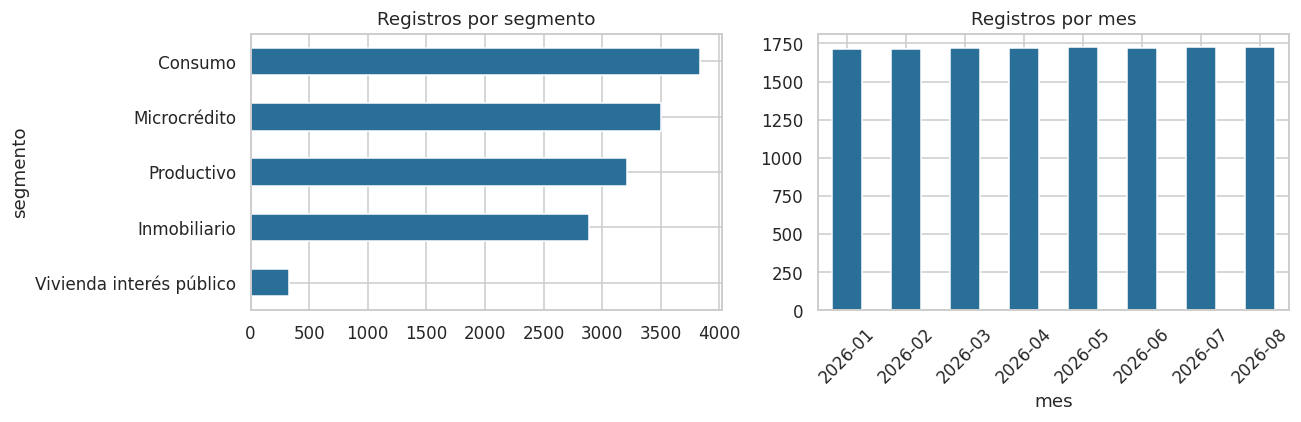

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["segmento"].value_counts().sort_values().plot.barh(ax=ax[0], color="#2a6f97")
ax[0].set_title("Registros por segmento")
df.groupby("mes").size().plot.bar(ax=ax[1], color="#2a6f97", rot=45)
ax[1].set_title("Registros por mes")
plt.tight_layout()
plt.show()

**Estadísticos descriptivos.** Estadísticos descriptivos (media, mediana, cuartiles, percentil 95) y asimetría. La media del saldo es muy superior a la mediana y la asimetría es alta: pocos cantones concentran casi todo el dinero.

In [9]:
resumen = df[["saldo_total", "improductiva", "morosidad_pct"]].describe(percentiles=[.25, .5, .75, .95]).T
resumen["asimetria"] = df[["saldo_total", "improductiva", "morosidad_pct"]].skew()
display(resumen)

,count,mean,std,min,25%,50%,75%,95%,max,asimetria
saldo_total,"13,765.00","31,042,468.08","196,947,993.21",0.32,"281,583.84","2,297,191.76","9,430,676.03","77,239,744.74","5,068,613,547.59",13.95
improductiva,"13,765.00","970,539.84","7,023,410.46",0.00,10.00,"85,504.29","404,020.83","2,768,912.37","213,768,266.73",20.65
morosidad_pct,"13,765.00",12.21,25.07,0.00,0.29,3.73,8.75,100.00,100.00,2.89


**Distribución de saldo y morosidad.** Histogramas de saldo (en escala logarítmica, porque cubre desde pocos dólares hasta miles de millones) y de morosidad. La morosidad muestra picos en 0% y en 100%: son filas con saldos mínimos, lo que se trata en el paso 5.

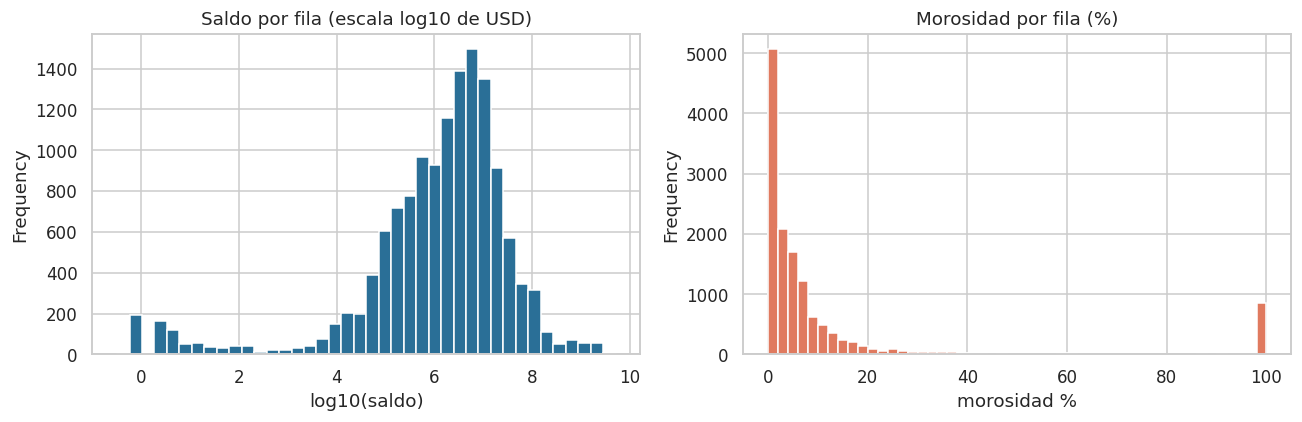

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
np.log10(df.loc[df["saldo_total"] > 0, "saldo_total"]).plot.hist(bins=40, ax=ax[0], color="#2a6f97")
ax[0].set_title("Saldo por fila (escala log10 de USD)")
ax[0].set_xlabel("log10(saldo)")
df["morosidad_pct"].plot.hist(bins=50, ax=ax[1], color="#e07a5f")
ax[1].set_title("Morosidad por fila (%)")
ax[1].set_xlabel("morosidad %")
plt.tight_layout()
plt.show()

**Peso de cada segmento.** Tabla del último mes por segmento: saldo, improductiva, morosidad ponderada y qué porcentaje del saldo y de la improductiva total aporta cada uno. Permite comparar el peso en porcentaje contra el peso en dólares.

In [11]:
ULT = df["mes"].max()                 # ultimo mes disponible
ago = df[df["mes"] == ULT]

seg = ago.groupby("segmento")[["saldo_total", "improductiva"]].sum()
seg["morosidad_pct"] = seg["improductiva"] / seg["saldo_total"] * 100
seg["peso_saldo_pct"] = seg["saldo_total"] / seg["saldo_total"].sum() * 100
seg["peso_improductiva_pct"] = seg["improductiva"] / seg["improductiva"].sum() * 100
print("Corte:", ULT)
display(seg.sort_values("morosidad_pct", ascending=False).round(2))

Corte: 2026-08


,saldo_total,improductiva,morosidad_pct,peso_saldo_pct,peso_improductiva_pct
segmento,,,,,
Microcrédito,"3,917,514,526.82","250,030,410.17",6.38,7.10,14.61
Consumo,"22,177,639,692.50","1,099,792,242.53",4.96,40.19,64.27
Inmobiliario,"2,860,769,091.38","80,723,221.58",2.82,5.18,4.72
Vivienda interés público,"72,003,901.65","965,414.35",1.34,0.13,0.06
Productivo,"26,152,627,395.73","279,706,485.39",1.07,47.39,16.35


**Entidades más grandes.** Ranking de las 12 entidades con mayor cartera. Muestra que el sistema está concentrado en pocos bancos grandes.

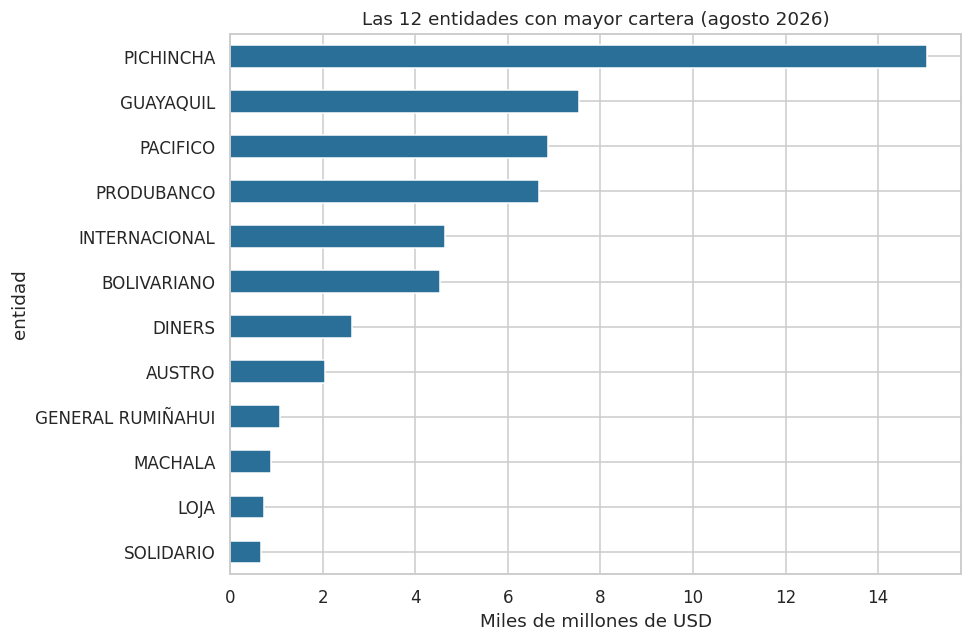

In [12]:
ent = ago.groupby("entidad")[["saldo_total", "improductiva"]].sum().sort_values("saldo_total")
fig, ax = plt.subplots(figsize=(9, 6))
(ent["saldo_total"] / 1e9).tail(12).plot.barh(ax=ax, color="#2a6f97")
ax.set_title("Las 12 entidades con mayor cartera (agosto 2026)")
ax.set_xlabel("Miles de millones de USD")
plt.tight_layout()
plt.show()

## Paso 4 · Análisis bivariado

Se relacionan pares de variables: segmento con morosidad, tiempo con morosidad, región con segmento y tamaño de saldo con morosidad.

**Morosidad por segmento en el tiempo.** Relación tiempo-morosidad por segmento. Se agrupa por mes y segmento, se suman saldo e improductiva y se calcula la morosidad ponderada. Microcrédito y consumo se mantienen más altos que productivo e inmobiliario durante todo el periodo.

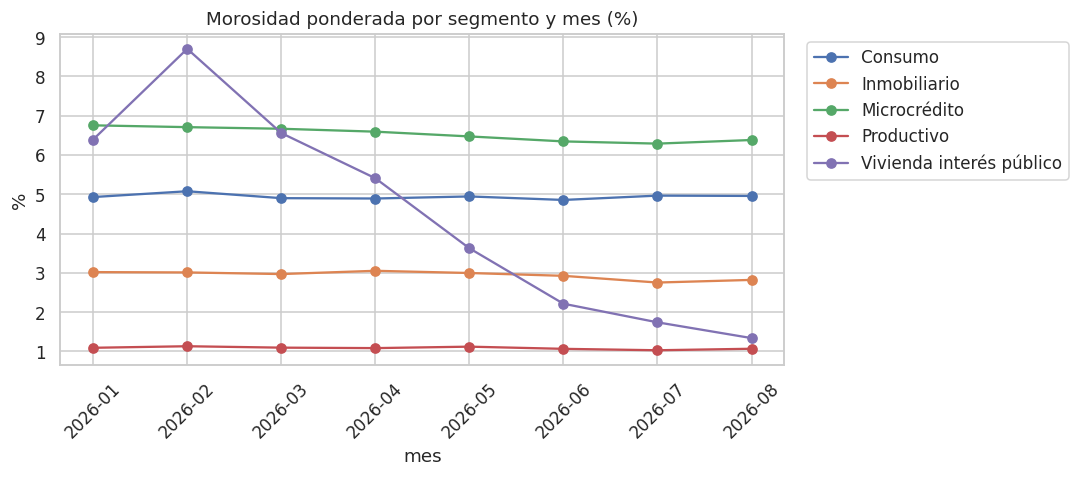

In [13]:
mes_seg = df.groupby(["mes", "segmento"])[["saldo_total", "improductiva"]].sum()
mes_seg["morosidad_pct"] = mes_seg["improductiva"] / mes_seg["saldo_total"] * 100
tabla_mes = mes_seg["morosidad_pct"].unstack()

tabla_mes.plot(figsize=(10, 4.5), marker="o")
plt.title("Morosidad ponderada por segmento y mes (%)")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Segmento x región.** Mapa de calor segmento por región. Cruza dos variables categóricas con la morosidad ponderada. Ayuda a ver dónde se concentra el riesgo dentro de cada tipo de crédito. Las celdas vacías significan que no hay cartera de ese segmento en esa región.

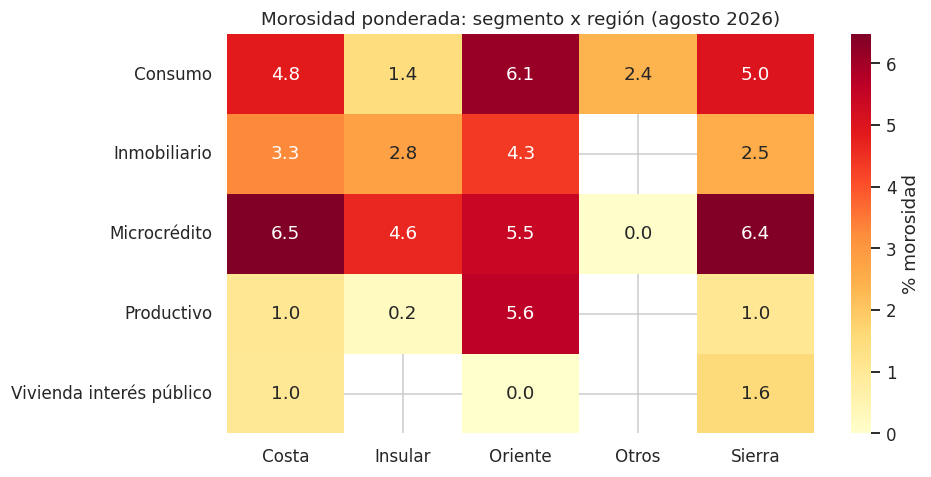

In [14]:
hm = ago.groupby(["segmento", "region"])[["saldo_total", "improductiva"]].sum()
hm["morosidad_pct"] = hm["improductiva"] / hm["saldo_total"] * 100
plt.figure(figsize=(9, 4.5))
sns.heatmap(hm["morosidad_pct"].unstack(), annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% morosidad"})
plt.title("Morosidad ponderada: segmento x región (agosto 2026)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Saldo vs morosidad.** Dispersión entre tamaño del saldo y morosidad. Se ve un embudo: con saldos pequeños la morosidad salta entre 0% y 100%, y con saldos grandes se estabiliza. Es evidencia de que los porcentajes de filas pequeñas son ruido, y justifica el paso 5. Se usa correlación de Spearman porque el saldo está muy sesgado.

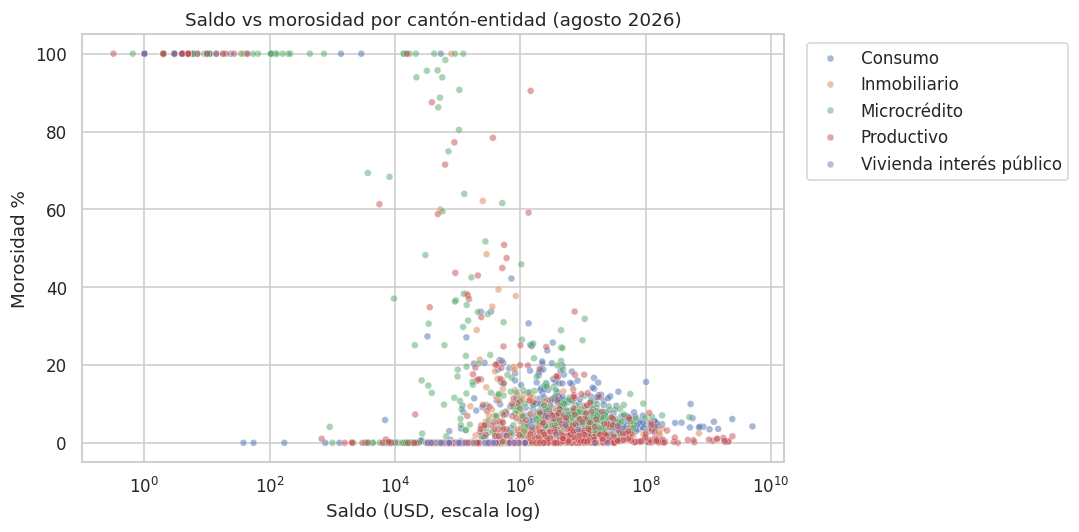

Correlacion de Spearman saldo-morosidad: 0.01


In [15]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=ago[ago["saldo_total"] > 0], x="saldo_total", y="morosidad_pct",
                hue="segmento", alpha=0.5, s=20)
plt.xscale("log")
plt.title("Saldo vs morosidad por cantón-entidad (agosto 2026)")
plt.xlabel("Saldo (USD, escala log)")
plt.ylabel("Morosidad %")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="")
plt.tight_layout()
plt.show()

print("Correlacion de Spearman saldo-morosidad:",
      round(ago[["saldo_total", "morosidad_pct"]].corr(method="spearman").iloc[0, 1], 3))

**Boxplot por segmento.** Diagrama de cajas de la morosidad por segmento, sin filtrar. Los muchos puntos extremos anticipan el tratamiento de atípicos del siguiente paso.

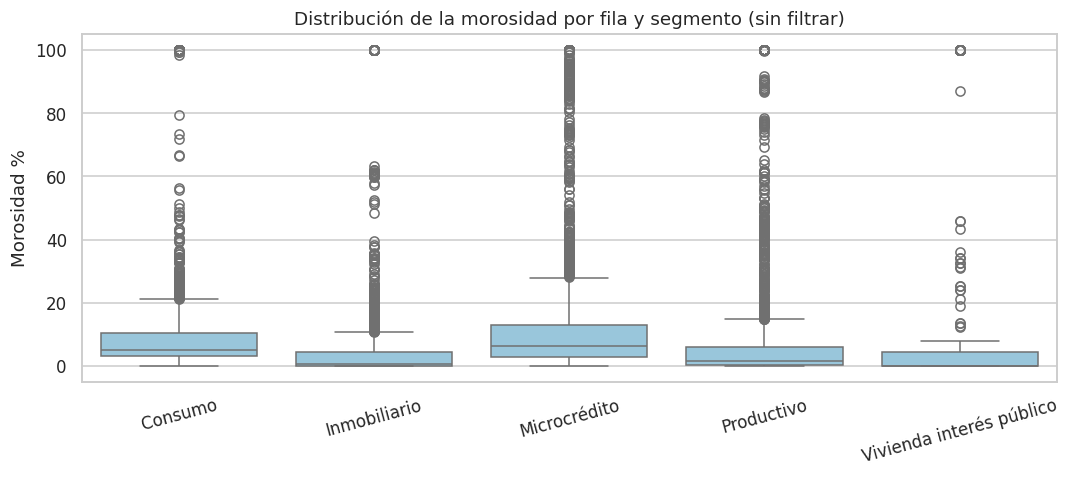

In [16]:
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df[df["saldo_total"] > 0], x="segmento", y="morosidad_pct", color="#8ecae6")
plt.title("Distribución de la morosidad por fila y segmento (sin filtrar)")
plt.xticks(rotation=15)
plt.xlabel("")
plt.ylabel("Morosidad %")
plt.tight_layout()
plt.show()

## Paso 5 · Faltantes y atípicos

Se revisa qué falta, qué es extremo y qué hacer con ello.

**Faltantes.** Busca datos faltantes y valores imposibles. No hay nulos ni montos negativos. La morosidad queda como NaN solo cuando el saldo es 0, porque dividir entre cero no está definido. No se imputa nada.

In [17]:
nulos = df.isna().sum()
print("Columnas con nulos:", nulos[nulos > 0].to_dict())
print("Filas con saldo 0 (morosidad indefinida):", (df["saldo_total"] == 0).sum())
print("Valores negativos en montos:", (df[["por_vencer", "no_devenga", "vencida", "saldo_total"]] < 0).sum().sum())

Columnas con nulos: {}
Filas con saldo 0 (morosidad indefinida): 0
Valores negativos en montos: 0


**Atípicos con IQR.** Detecta atípicos con la regla del rango intercuartílico (IQR): se consideran atípicos los valores fuera de Q1 - 1,5·IQR y Q3 + 1,5·IQR. Se aplica a saldo y a morosidad.

In [18]:
def limites_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    i = q3 - q1
    return q1 - 1.5 * i, q3 + 1.5 * i

for col in ["saldo_total", "morosidad_pct"]:
    lo, hi = limites_iqr(df[col].dropna())
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: limites IQR = [{lo:,.1f}; {hi:,.1f}] -> {n} filas atipicas ({n/len(df):.1%})")

saldo_total: limites IQR = [-13,442,054.4; 23,154,314.3] -> 1693 filas atipicas (12.3%)
morosidad_pct: limites IQR = [-12.4; 21.5] -> 1560 filas atipicas (11.3%)


**Filas de saldo mínimo.** Cuantifica el problema: alrededor del 16% de las filas tiene saldo menor a USD 100 mil, pero pesan una fracción mínima del saldo total. Casi todas las filas con morosidad de 100% son de saldos diminutos. Son atípicos por tamaño, no por riesgo real.

In [19]:
MIN_SALDO = 100_000          # supuesto: menos de USD 100 mil no permite medir una tasa con sentido
pequenas = df[df["saldo_total"] < MIN_SALDO]

print(f"Filas con saldo < USD {MIN_SALDO:,}: {len(pequenas):,} ({len(pequenas)/len(df):.1%} de las filas)")
print(f"  ...pero solo {pequenas['saldo_total'].sum()/df['saldo_total'].sum():.3%} del saldo total")
print(f"  ...y {pequenas['improductiva'].sum()/df['improductiva'].sum():.3%} de la improductiva total")
print("Filas con morosidad >= 99.9%:", (df["morosidad_pct"] >= 99.9).sum())
print("  de ellas con saldo < 100 mil:", ((df["morosidad_pct"] >= 99.9) & (df["saldo_total"] < MIN_SALDO)).sum())

Filas con saldo < USD 100,000: 2,173 (15.8% de las filas)
  ...pero solo 0.014% del saldo total
  ...y 0.063% de la improductiva total
Filas con morosidad >= 99.9%: 833
  de ellas con saldo < 100 mil: 826


**Antes y después del filtro.** Aplica el tratamiento y compara antes y después con boxplots. Tras filtrar por saldo mínimo, la dispersión extrema desaparece y quedan tasas comparables.

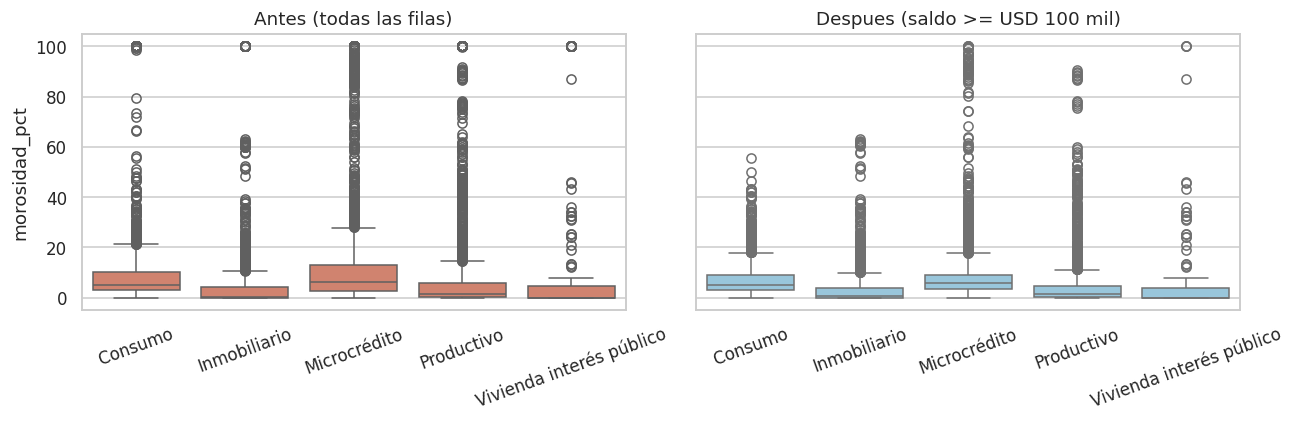

In [20]:
analisis = df[df["saldo_total"] >= MIN_SALDO].copy()   # para rankings a nivel canton-entidad

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.boxplot(data=df[df["saldo_total"] > 0], x="segmento", y="morosidad_pct", color="#e07a5f", ax=ax[0])
ax[0].set_title("Antes (todas las filas)")
sns.boxplot(data=analisis, x="segmento", y="morosidad_pct", color="#8ecae6", ax=ax[1])
ax[1].set_title("Despues (saldo >= USD 100 mil)")
for a_ in ax:
    a_.set_xlabel("")
    a_.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Decisión metodológica sobre atípicos (queda documentada para la exposición)**
- Los indicadores agregados (por segmento, región, entidad, mes) se calculan **ponderados con todos los datos**: los saldos pequeños casi no pesan, así que no distorsionan y no se elimina información.
- Los **rankings a nivel cantón-entidad** usan solo filas con saldo >= USD 100.000, para no confundir ruido con riesgo.
- **No se imputa** ningún valor: no hay nulos reales.

## Paso 6 · Segmentación

Se divide el riesgo por segmento de crédito, región, provincia y entidad.

**Segmento: evolución y crecimiento.** Segmentación por tipo de crédito: morosidad de enero contra agosto, variación en puntos porcentuales y crecimiento de la cartera en el periodo. Vivienda de interés público tiene un crecimiento enorme pero parte de una base muy pequeña, por lo que hay que interpretarlo con cuidado.

In [21]:
saldo_mes = df.groupby(["mes", "segmento"])["saldo_total"].sum().unstack()
cambio = pd.DataFrame({
    "morosidad_ene": tabla_mes.iloc[0],
    "morosidad_ago": tabla_mes.iloc[-1],
})
cambio["var_pp"] = cambio["morosidad_ago"] - cambio["morosidad_ene"]
cambio["crecimiento_cartera_pct"] = (saldo_mes.iloc[-1] / saldo_mes.iloc[0] - 1) * 100
display(cambio.sort_values("morosidad_ago", ascending=False).round(2))

,morosidad_ene,morosidad_ago,var_pp,crecimiento_cartera_pct
segmento,,,,
Microcrédito,6.76,6.38,-0.37,7.28
Consumo,4.93,4.96,0.03,5.70
Inmobiliario,3.02,2.82,-0.20,4.15
Vivienda interés público,6.39,1.34,-5.05,304.65
Productivo,1.09,1.07,-0.02,8.73


**Región: tasa y dólares.** Segmentación por región, mostrando lado a lado el porcentaje y los dólares. Sirve para contrastar la hipótesis H2 (diferencias regionales). Se debe leer con ambos gráficos: una región puede tener tasa alta pero pocos dólares en juego.

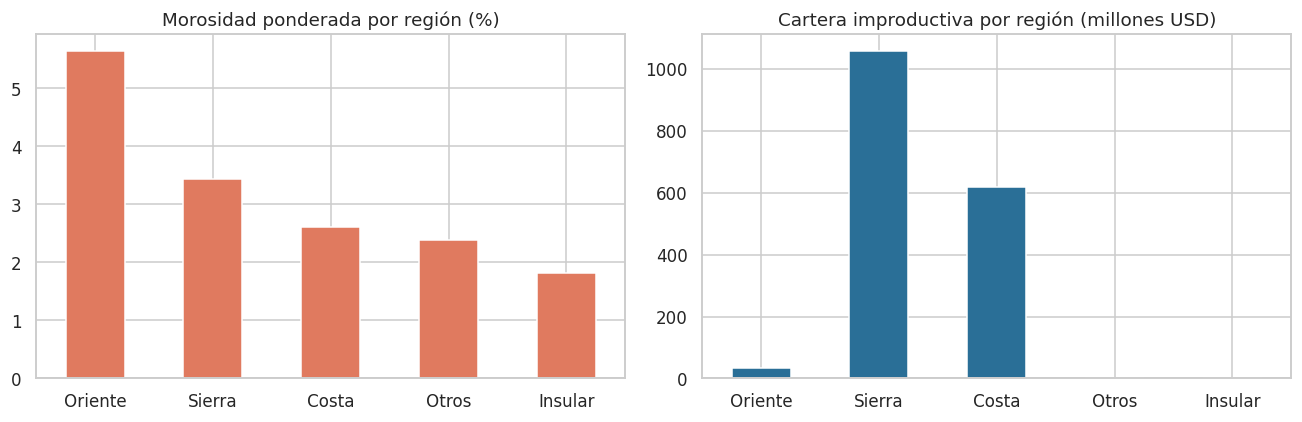

,saldo_total,improductiva,morosidad_pct
region,,,
Oriente,"597,859,483.14","33,774,015.73",5.65
Sierra,"30,844,228,298.06","1,058,148,402.74",3.43
Costa,"23,670,194,434.74","618,045,375.23",2.61
Otros,"677,663.51","16,122.27",2.38
Insular,"67,594,728.63","1,233,858.05",1.83


In [22]:
reg = ago.groupby("region")[["saldo_total", "improductiva"]].sum()
reg["morosidad_pct"] = reg["improductiva"] / reg["saldo_total"] * 100
reg = reg.sort_values("morosidad_pct", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
reg["morosidad_pct"].plot.bar(ax=ax[0], color="#e07a5f", rot=0)
ax[0].set_title("Morosidad ponderada por región (%)")
(reg["improductiva"] / 1e6).plot.bar(ax=ax[1], color="#2a6f97", rot=0)
ax[1].set_title("Cartera improductiva por región (millones USD)")
for a_ in ax:
    a_.set_xlabel("")
plt.tight_layout()
plt.show()
display(reg.round(2))

**Provincias más morosas.** Ranking de las 10 provincias con más morosidad ponderada, excluyendo las de cartera muy pequeña para no comparar tasas sobre montos mínimos. La línea punteada marca el promedio del sistema.

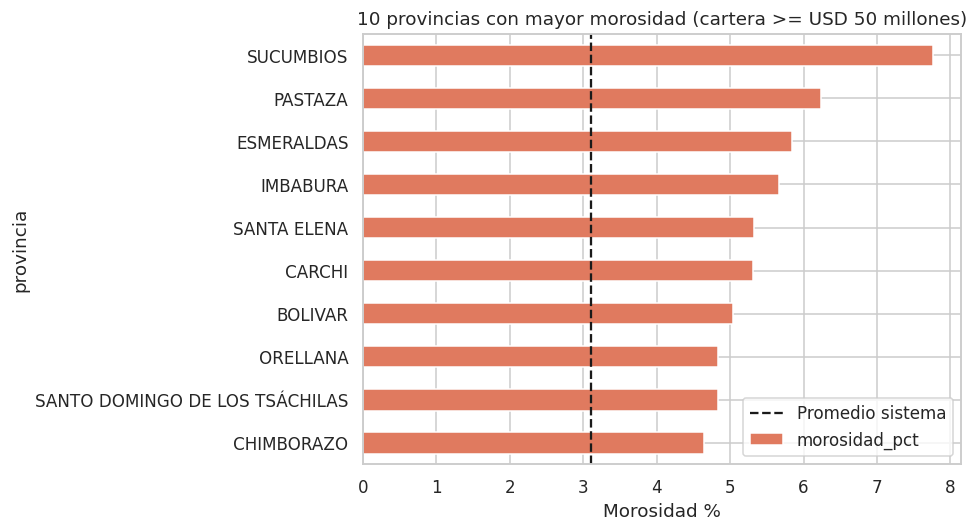

In [23]:
PROV_MIN = 50_000_000                    # solo provincias con al menos USD 50 millones de cartera
prov = ago.groupby("provincia")[["saldo_total", "improductiva"]].sum()
prov["morosidad_pct"] = prov["improductiva"] / prov["saldo_total"] * 100
top_prov = prov[prov["saldo_total"] >= PROV_MIN].sort_values("morosidad_pct", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_prov["morosidad_pct"].sort_values().plot.barh(ax=ax, color="#e07a5f")
ax.axvline(ago["improductiva"].sum() / ago["saldo_total"].sum() * 100, color="k", ls="--", label="Promedio sistema")
ax.set_title("10 provincias con mayor morosidad (cartera >= USD 50 millones)")
ax.set_xlabel("Morosidad %")
ax.legend()
plt.tight_layout()
plt.show()

**Matriz de riesgo por entidad.** Matriz de riesgo por entidad. Cada burbuja es un banco: eje X = tamaño de cartera, eje Y = morosidad, tamaño = dólares improductivos. Los bancos se clasifican en pequeño, mediano y grande por terciles de cartera. La línea punteada es la morosidad promedio del sistema.

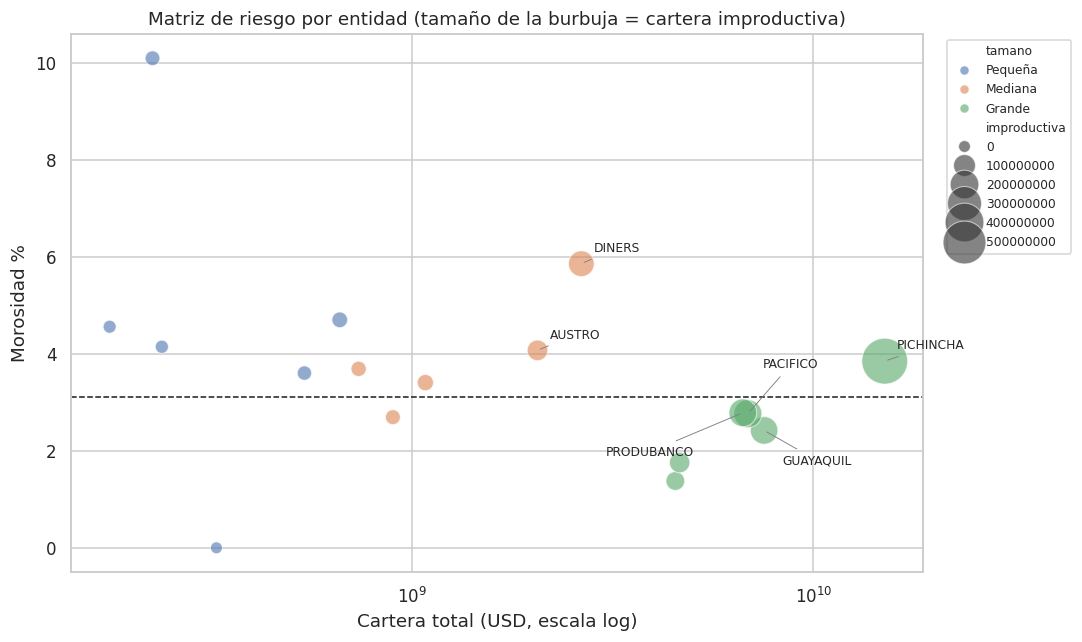

In [24]:
ENT_MIN = 100_000_000                    # entidades con al menos USD 100 millones
en = ago.groupby("entidad")[["saldo_total", "improductiva"]].sum()
en["morosidad_pct"] = en["improductiva"] / en["saldo_total"] * 100
en = en[en["saldo_total"] >= ENT_MIN].copy()
en["tamano"] = pd.qcut(en["saldo_total"], 3, labels=["Pequeña", "Mediana", "Grande"])
prom = ago["improductiva"].sum() / ago["saldo_total"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=en, x="saldo_total", y="morosidad_pct", size="improductiva",
                hue="tamano", sizes=(60, 900), alpha=0.6, ax=ax)
ax.axhline(prom, color="k", ls="--", lw=1)
ax.set_xscale("log")
ax.set_title("Matriz de riesgo por entidad (tamaño de la burbuja = cartera improductiva)")
ax.set_xlabel("Cartera total (USD, escala log)")
ax.set_ylabel("Morosidad %")
desplazamientos = [(8, 8), (10, 30), (-90, -28), (12, -22), (8, 8), (8, 8)]   # evita que se superpongan
top6 = en.sort_values("improductiva", ascending=False).head(6)
for (nombre, fila), desp in zip(top6.iterrows(), desplazamientos):
    ax.annotate(nombre, (fila["saldo_total"], fila["morosidad_pct"]), fontsize=8,
                xytext=desp, textcoords="offset points",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="gray"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Concentración de la improductiva.** Análisis de concentración (tipo Pareto): ordena las entidades por dólares improductivos y calcula el porcentaje acumulado. Contrasta la hipótesis H3.

In [25]:
pareto = (ago.groupby("entidad")["improductiva"].sum().sort_values(ascending=False))
pareto_df = pd.DataFrame({"improductiva_musd": pareto / 1e6, "acumulado_pct": pareto.cumsum() / pareto.sum() * 100})
display(pareto_df.head(8).round(1))
print(f"Las 5 primeras entidades concentran {pareto_df['acumulado_pct'].iloc[4]:.1f}% de la cartera improductiva")

,improductiva_musd,acumulado_pct
entidad,,
PICHINCHA,579.30,33.90
PACIFICO,189.80,44.90
PRODUBANCO,185.70,55.80
GUAYAQUIL,182.40,66.50
DINERS,154.80,75.50
AUSTRO,83.70,80.40
INTERNACIONAL,81.60,85.20
BOLIVARIANO,62.40,88.80


Las 5 primeras entidades concentran 75.5% de la cartera improductiva


**Cantones con más improductiva.** Los 8 cantones con más dólares improductivos (usando solo filas con saldo mínimo, según el paso 5). Muestra dónde está el problema en términos absolutos.

In [26]:
cant = analisis[analisis["mes"] == ULT].groupby(["provincia", "canton"])[["saldo_total", "improductiva"]].sum()
cant["morosidad_pct"] = cant["improductiva"] / cant["saldo_total"] * 100
display(cant.sort_values("improductiva", ascending=False).head(8).round(1))

,,saldo_total,improductiva,morosidad_pct
provincia,canton,,,
PICHINCHA,QUITO,"22,525,431,091.70","768,965,571.30",3.40
GUAYAS,GUAYAQUIL,"17,265,839,467.40","351,881,949.20",2.00
MANABI,MANTA,"1,228,148,885.50","48,200,979.10",3.90
AZUAY,CUENCA,"2,704,195,397.80","43,411,887.00",1.60
EL ORO,MACHALA,"1,362,852,697.20","40,301,687.10",3.00
SANTO DOMINGO DE LOS TSÁCHILAS,SANTO DOMINGO,"748,782,301.30","36,982,729.80",4.90
IMBABURA,IBARRA,"550,721,678.80","31,760,136.20",5.80
TUNGURAHUA,AMBATO,"1,123,500,450.40","31,570,499.80",2.80


## Paso 7 · Hallazgos

Las cifras de abajo se calculan con código para que coincidan siempre con los datos.

**Hallazgos calculados.** Calcula y muestra las conclusiones numéricas a partir de las tablas construidas en los pasos anteriores. Así el texto nunca queda desactualizado respecto a los datos.

In [27]:
tot = ago["improductiva"].sum() / ago["saldo_total"].sum() * 100
ene = df[df["mes"] == df["mes"].min()]
tot_ene = ene["improductiva"].sum() / ene["saldo_total"].sum() * 100

print(f"1. Morosidad total banca privada: {tot:.2f}% en {ULT} (enero: {tot_ene:.2f}%).")
top_seg = seg.sort_values("morosidad_pct", ascending=False)
print(f"2. Segmento mas moroso: {top_seg.index[0]} ({top_seg['morosidad_pct'].iloc[0]:.2f}%); "
      f"el menos moroso: {top_seg.index[-1]} ({top_seg['morosidad_pct'].iloc[-1]:.2f}%).")
mayor_usd = seg["improductiva"].idxmax()
print(f"3. En dolares, {mayor_usd} concentra {seg.loc[mayor_usd, 'peso_improductiva_pct']:.1f}% de la improductiva "
      f"(USD {seg.loc[mayor_usd, 'improductiva']/1e6:,.0f} millones).")
print(f"4. Region con mayor tasa: {reg.index[0]} ({reg['morosidad_pct'].iloc[0]:.2f}%), "
      f"pero la region con mas dolares improductivos es {reg['improductiva'].idxmax()} "
      f"(USD {reg['improductiva'].max()/1e6:,.0f} millones).")
print(f"5. Provincia mas morosa (cartera >= USD 50 millones): {top_prov.index[0]} ({top_prov['morosidad_pct'].iloc[0]:.2f}%).")
print(f"6. Las 5 entidades con mas improductiva concentran {pareto_df['acumulado_pct'].iloc[4]:.1f}% del total; "
      f"la primera es {pareto_df.index[0]}.")
grandes = seg.index[seg["peso_saldo_pct"] >= 1]          # se ignoran segmentos con menos de 1% del saldo
sube = cambio.loc[grandes, "var_pp"].sort_values()
print(f"7. Variacion ene-ago (segmentos con >= 1% del saldo): mayor baja en {sube.index[0]} ({sube.iloc[0]:+.2f} pp); "
      f"mayor alza en {sube.index[-1]} ({sube.iloc[-1]:+.2f} pp).")

1. Morosidad total banca privada: 3.10% en 2026-08 (enero: 3.17%).
2. Segmento mas moroso: Microcrédito (6.38%); el menos moroso: Productivo (1.07%).
3. En dolares, Consumo concentra 64.3% de la improductiva (USD 1,100 millones).
4. Region con mayor tasa: Oriente (5.65%), pero la region con mas dolares improductivos es Sierra (USD 1,058 millones).
5. Provincia mas morosa (cartera >= USD 50 millones): SUCUMBIOS (7.76%).
6. Las 5 entidades con mas improductiva concentran 75.5% del total; la primera es PICHINCHA.
7. Variacion ene-ago (segmentos con >= 1% del saldo): mayor baja en Microcrédito (-0.37 pp); mayor alza en Consumo (+0.03 pp).


**Lectura de las hipótesis**
- **H1 (se cumple):** microcrédito y consumo son los segmentos más morosos, y productivo el menos. Pero en dólares, consumo concentra la mayor parte de la cartera improductiva porque su saldo es mucho mayor que el del microcrédito.
- **H2 (se cumple parcialmente, y con un matiz):** la Costa no es la región más morosa. En el corte de agosto la Sierra tiene mayor tasa que la Costa, y el Oriente tiene la tasa más alta pero con muy pocos dólares. Esto no descarta el riesgo de El Niño: los datos son de enero a agosto, antes de que se materialice cualquier efecto climático, así que sirven de línea base para monitorear.
- **H3 (se cumple):** cinco entidades concentran cerca de tres cuartas partes de la cartera improductiva, con BP Pichincha a la cabeza por su tamaño.

**Decisiones que se pueden tomar**
1. **Provisiones:** priorizar consumo (mayor exposición en dólares) y microcrédito (mayor tasa), sobre todo en las entidades de la matriz de riesgo con morosidad por encima del promedio del sistema.
2. **Colocación:** productivo e inmobiliario combinan morosidad baja y estabilidad; son los candidatos para ampliar cartera, revisando región por región en el dashboard.
3. **Monitoreo climático:** usar el tablero mes a mes para detectar si la morosidad de las provincias costeras sube desde septiembre, y actuar antes de que el deterioro sea grande.

**Limitaciones (para responder preguntas del docente)**
- Solo banca privada: no incluye cooperativas ni banca pública.
- No hay datos de provisiones, por lo que no se calcula cobertura.
- Ocho meses de datos: sirve para tendencia corta, no para estacionalidad anual.
- La morosidad aquí es cartera improductiva sobre saldo, definida por nosotros; puede diferir levemente de la cifra oficial publicada por la Superintendencia.
- La asociación entre variables no prueba causalidad.